In [2]:
import numpy as np
from mydezero import Variable
import mydezero.functions as F

In [3]:
# Hyper Parameters
lr = 0.2
iters = 10000

In [4]:
# Data Set
np.random.seed(0)
x = np.random.rand(100, 1)
y = np.sin(2 * np.pi * x) + np.random.rand(100, 1)

In [5]:
# Initialize
I, H, O = 1, 10, 1
W1 = Variable(0.01 * np.random.rand(I, H))
b1 = Variable(np.zeros(H))
W2 = Variable(0.01 * np.random.rand(H, O))
b2 = Variable(np.zeros(O))

In [6]:
# Model Structure
def predict(x):
    y = F.linear(x, W1, b1)
    y = F.sigmoid(y)
    y = F.linear(y, W2, b2)
    return y

In [7]:
# Train
for i in range(iters):
    y_pred = predict(x)
    loss = F.mean_squared_error(y, y_pred)

    W1.cleargrad()
    b1.cleargrad()
    W2.cleargrad()
    b2.cleargrad()
    loss.backward()

    W1.data -= lr * W1.grad.data
    b1.data -= lr * b1.grad.data
    W2.data -= lr * W2.grad.data
    b2.data -= lr * b2.grad.data

    if i % 1000 == 0:
        print(loss)

variable(0.8209681612957712)
variable(0.25326725620755336)
variable(0.25227344650888284)
variable(0.25107907592030493)
variable(0.2492465513235277)
variable(0.2458887759834958)
variable(0.23931652204339046)
variable(0.22664935772724248)
variable(0.19660157730769384)
variable(0.11754542250018861)


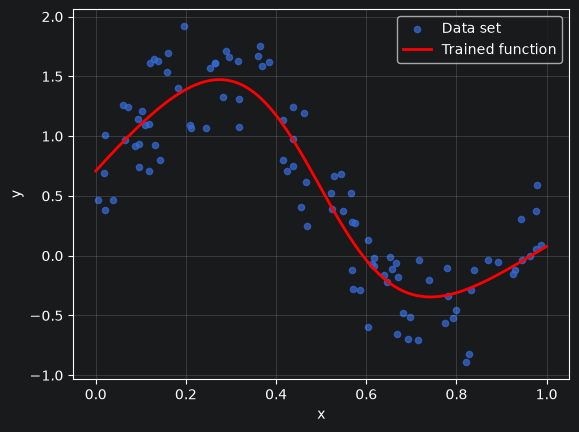

In [8]:
# Draw the data set and the trained function
import matplotlib.pyplot as plt

x_plot = np.linspace(0, 1, 200).reshape(-1, 1)
y_plot = predict(x_plot).data

plt.scatter(x, y, s=20, alpha=0.7, label="Data set")
plt.plot(x_plot, y_plot, color="red", linewidth=2, label="Trained function")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()